# CXRFEScore demo

Illustrative walkthrough of the [`cxrfescore`](https://pypi.org/project/cxrfescore/) package: scoring report pairs, fact extraction / embedding, caching, and fact-similarity visualizations.

Based on [Messina et al., Findings of ACL 2024](https://aclanthology.org/2024.findings-acl.236/).

- **PyPI:** https://pypi.org/project/cxrfescore/
- **Package repo:** https://github.com/PabloMessina/CXRFEScore
- **Default encoder:** [`pamessina/CXRFE`](https://huggingface.co/pamessina/CXRFE)
- **Fact extractor:** [`pamessina/T5FactExtractor`](https://huggingface.co/pamessina/T5FactExtractor)

## How to run

### Local Jupyter

1. Create / activate an environment with Python 3.10+.
2. Run the install cell below (`pip install` from PyPI).
3. **Restart the kernel** after installing/upgrading, then run the remaining cells top-to-bottom.
4. A GPU is recommended but not required.

### Google Colab

1. Open this notebook via **Open in Colab** (see the repo README badge), or upload it.
2. Runtime → Change runtime type → **GPU** (T4 is enough).
3. Run the install cell, restart the runtime if prompted, then run the rest in order.

> First run downloads Hugging Face models and NLTK data. Later cells reuse an in-memory cache; call `save_cache()` if you want disk persistence.


## 0. Install

Installs **cxrfescore ≥ 0.2.3** from PyPI (with the optional viz extra for heatmaps).


In [1]:
%pip install -q -U "cxrfescore[viz]"

Note: you may need to restart the kernel to use updated packages.


## 1. Imports and device

In [2]:
import warnings

# Belt-and-suspenders: hush known HF/torch deprecation noise in notebook outputs.
warnings.filterwarnings(
    "ignore",
    message=r".*encoder_attention_mask.*",
    category=FutureWarning,
)

import torch
import cxrfescore
from cxrfescore import CXRFEScore, inspect_cache

device = "cuda" if torch.cuda.is_available() else "cpu"
print("cxrfescore:", cxrfescore.__version__)
print("torch:", torch.__version__)
print("device:", device)

if tuple(int(x) for x in cxrfescore.__version__.split(".")[:3]) < (0, 2, 3):
    print(
        "NOTE: cxrfescore < 0.2.3 — re-run the install cell and restart the kernel "
        "for labeled progress bars / quieter warnings."
    )

cxrfescore: 0.2.3
torch: 2.6.0+cu124
device: cuda


## 2. Basic scoring with the default encoder (CXRFE)

`CXRFEScore` extracts facts from each report, embeds them, and returns a soft bipartite-matching similarity between hypothesis and reference.

In [3]:
metric = CXRFEScore(
    device=device,
    batch_size=8,
    num_workers=0,
    verbose=True,
)

hyps = [
    "There is a small right pleural effusion. The heart size is normal.",
    "Large left pneumothorax with mediastinal shift.",
]
refs = [
    "Small right pleural effusion. Normal heart size.",
    "No acute cardiopulmonary process. Lungs are clear.",
]

result = metric(hyps, refs)
print("mean_similarity:", result["mean_similarity"])
print("per_pair_similarity:", result["per_pair_similarity"])
print(
    "Similar paraphrase scores higher than unrelated pair:",
    float(result["per_pair_similarity"][0]) > float(result["per_pair_similarity"][1]),
)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Extracting facts:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pair-wise similarity:   0%|          | 0/2 [00:00<?, ?it/s]

mean_similarity: 0.38984715938568115
per_pair_similarity: [ 1.         -0.22030568]
Similar paraphrase scores higher than unrelated pair: True


## 3. Challenging / adversarial pairs

These cases stress clinical nuances (negation, laterality, severity, synonyms, devices). A good metric should score clinically wrong pairs lower than near-paraphrases.

In [4]:
adversarial_cases = [
    {
        "name": "Negation flip (should score LOW)",
        "note": "Nearly identical wording, opposite clinical meaning.",
        "ref": "There is no evidence of pneumothorax.",
        "hyp": "There is evidence of pneumothorax.",
    },
    {
        "name": "Laterality swap (should score LOW)",
        "note": "Same finding, wrong side — clinically important error.",
        "ref": "Moderate right pleural effusion.",
        "hyp": "Moderate left pleural effusion.",
    },
    {
        "name": "Severity / size swap (should score MID-LOW)",
        "note": "Correct finding/side, wrong magnitude.",
        "ref": "Small right pleural effusion.",
        "hyp": "Large right pleural effusion.",
    },
    {
        "name": "Synonym paraphrase (should score HIGH)",
        "note": "Different wording, same meaning — robustness check.",
        "ref": "The heart is enlarged. There is pulmonary edema.",
        "hyp": "Cardiomegaly is present. Findings consistent with pulmonary oedema.",
    },
    {
        "name": "Presence vs absence of shared anatomy (should score LOW)",
        "note": "Shares anatomy tokens but asserts opposite finding.",
        "ref": "The lungs are clear without focal consolidation.",
        "hyp": "There is focal consolidation in the lungs.",
    },
    {
        "name": "Device / support device mismatch (should score LOW)",
        "note": "Support-device facts often confuse overlap-based metrics.",
        "ref": "Endotracheal tube tip is appropriately positioned above the carina.",
        "hyp": "Nasogastric tube tip is appropriately positioned in the stomach.",
    },
]

adv_hyps = [c["hyp"] for c in adversarial_cases]
adv_refs = [c["ref"] for c in adversarial_cases]
adv_result = metric(adv_hyps, adv_refs)

print("=== Adversarial pair scores (CXRFE) ===")
for case, score in zip(adversarial_cases, adv_result["per_pair_similarity"]):
    print(f"\n[{case['name']}] score={float(score):.4f}")
    print(f"  note: {case['note']}")
    print(f"  REF: {case['ref']}")
    print(f"  HYP: {case['hyp']}")

Extracting facts:   0%|          | 0/2 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Computing pair-wise similarity:   0%|          | 0/6 [00:00<?, ?it/s]

=== Adversarial pair scores (CXRFE) ===

[Negation flip (should score LOW)] score=-0.1796
  note: Nearly identical wording, opposite clinical meaning.
  REF: There is no evidence of pneumothorax.
  HYP: There is evidence of pneumothorax.

[Laterality swap (should score LOW)] score=0.3834
  note: Same finding, wrong side — clinically important error.
  REF: Moderate right pleural effusion.
  HYP: Moderate left pleural effusion.

[Severity / size swap (should score MID-LOW)] score=0.4808
  note: Correct finding/side, wrong magnitude.
  REF: Small right pleural effusion.
  HYP: Large right pleural effusion.

[Synonym paraphrase (should score HIGH)] score=0.8275
  note: Different wording, same meaning — robustness check.
  REF: The heart is enlarged. There is pulmonary edema.
  HYP: Cardiomegaly is present. Findings consistent with pulmonary oedema.

[Presence vs absence of shared anatomy (should score LOW)] score=0.1347
  note: Shares anatomy tokens but asserts opposite finding.
  REF: Th

In [5]:
scores = {
    c["name"]: float(s)
    for c, s in zip(adversarial_cases, adv_result["per_pair_similarity"])
}
synonym = scores["Synonym paraphrase (should score HIGH)"]
negation = scores["Negation flip (should score LOW)"]
laterality = scores["Laterality swap (should score LOW)"]

print(f"synonym={synonym:.4f}")
print(f"negation={negation:.4f}")
print(f"laterality={laterality:.4f}")

if synonym > negation and synonym > laterality:
    print("Relative ordering looks reasonable (synonym > negation/laterality).")
else:
    print("WARNING: inspect scores/heatmaps — synonym did not clearly outrank hard negatives.")

synonym=0.8275
negation=-0.1796
laterality=0.3834
Relative ordering looks reasonable (synonym > negation/laterality).


## 4. Extract facts and embeddings only

`extract_facts` treats each string as a **full report** (sentence-split → T5 extraction → unique-fact aggregation).  
`embed_facts` embeds already-extracted fact strings with the current encoder.

In [6]:
reports = [
    (
        "There is a small right pleural effusion. The heart size is mildly enlarged. "
        "Mild pulmonary edema is present. No pneumothorax."
    ),
]

facts_per_report = metric.extract_facts(reports)
print("Extracted facts:")
for i, fact in enumerate(facts_per_report[0], start=1):
    print(f"  {i}. {fact}")

embeddings = metric.embed_facts(facts_per_report[0])
print("\nEmbedding shape:", embeddings.shape)  # (num_facts, dim) — 128 for CXRFE

Extracting facts:   0%|          | 0/1 [00:00<?, ?it/s]

Extracted facts:
  1. small right pleural effusion
  2. mildly enlarged heart size
  3. mild pulmonary edema
  4. no pneumothorax


Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding shape: (4, 128)


## 5. Caching

With `use_cache=True` (default), sentence→facts and fact→embedding maps are kept **in memory** during the session. Disk writes happen only when you call `save_cache()`.

In [7]:
print("=== Cache before save_cache() ===")
inspect_cache()  # or: metric.inspect_cache()

metric.save_cache()

print("\n=== Cache after save_cache() ===")
inspect_cache()

=== Cache before save_cache() ===
CXRFEScore cache: /mnt/researchers/denis-parra/workspace_pamessina/.cache/cxrfescore
Cache directory does not exist yet.

=== Cache after save_cache() ===
CXRFEScore cache: /mnt/researchers/denis-parra/workspace_pamessina/.cache/cxrfescore

--- embeddings/pamessina__CXRFE/fact_to_embedding.pkl (12.48 KB) ---
entries: 22
  'no acute cardiopulmonary process' -> array shape=(128,) dtype=float32
  'normal heart size' -> array shape=(128,) dtype=float32
  'large left pneumothorax' -> array shape=(128,) dtype=float32
  'mediastinal shift' -> array shape=(128,) dtype=float32
  'clear lungs' -> array shape=(128,) dtype=float32
  ... (17 more)

--- sent_to_facts.pkl (1.63 KB) ---
entries: 23
  'Lungs are clear.' -> ['clear lungs']
  'Normal heart size.' -> ['normal heart size']
  'The heart size is normal.' -> ['normal heart size']
  'Small right pleural effusion.' -> ['small right pleural effusion']
  'No acute cardiopulmonary process.' -> ['no acute cardiopul

{'cache_dir': '/mnt/researchers/denis-parra/workspace_pamessina/.cache/cxrfescore',
 'exists': True,
 'files': [{'path': '/mnt/researchers/denis-parra/workspace_pamessina/.cache/cxrfescore/embeddings/pamessina__CXRFE/fact_to_embedding.pkl',
   'relative_path': 'embeddings/pamessina__CXRFE/fact_to_embedding.pkl',
   'size_bytes': 12777,
   'size_human': '12.48 KB',
   'entries': 22,
   'error': None,
   'samples': [{'key': 'no acute cardiopulmonary process',
     'value_kind': 'array',
     'shape': (128,),
     'dtype': 'float32'},
    {'key': 'normal heart size',
     'value_kind': 'array',
     'shape': (128,),
     'dtype': 'float32'},
    {'key': 'large left pneumothorax',
     'value_kind': 'array',
     'shape': (128,),
     'dtype': 'float32'},
    {'key': 'mediastinal shift',
     'value_kind': 'array',
     'shape': (128,),
     'dtype': 'float32'},
    {'key': 'clear lungs',
     'value_kind': 'array',
     'shape': (128,),
     'dtype': 'float32'}]},
  {'path': '/mnt/researc

## 6. Fact-similarity visualization (easy pair)

Requires `cxrfescore[viz]` (matplotlib). Heatmap cells are cosine similarities between candidate facts (rows) and reference facts (columns).

--- Candidate Report (Y-axis) ---
There is a small right pleural effusion. The heart size is normal.

--- Extracted Candidate Facts ---
- small right pleural effusion
- normal heart size

--- Reference Report (X-axis) ---
Small right pleural effusion. Normal heart size.

--- Extracted Reference Facts ---
- small right pleural effusion
- normal heart size


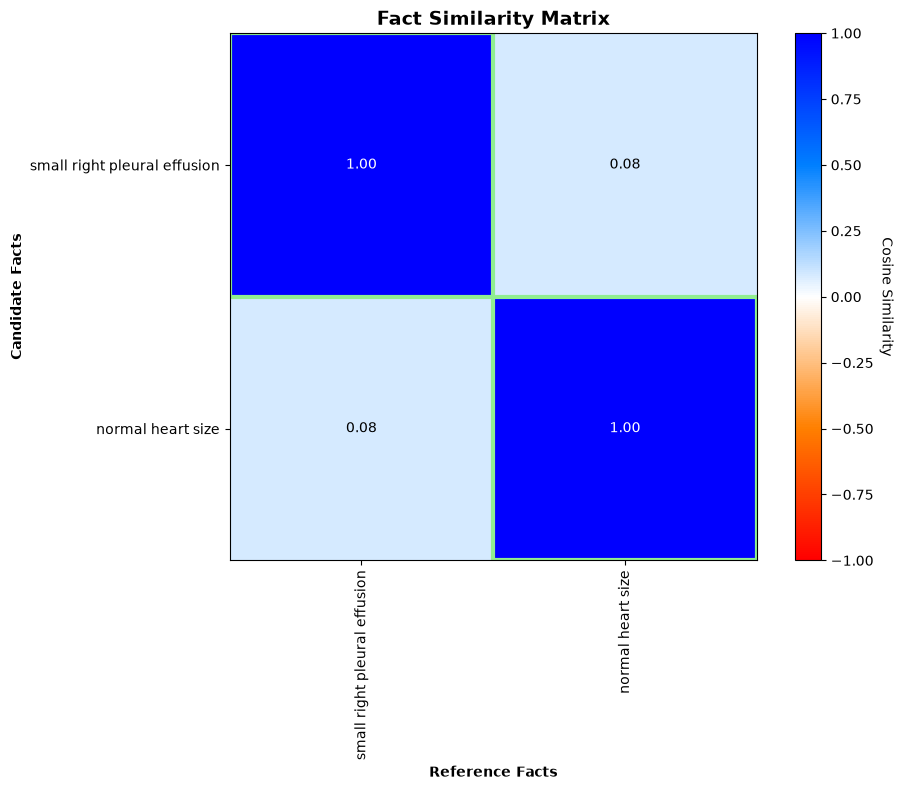


CXRFEScore for this pair: 1.0000


In [8]:
metric.visualize_fact_similarity(
    ref_report=refs[0],
    cand_report=hyps[0],
)

## 7. Multi-fact pair: CXRFE vs SRR-BERT-Leaves

Same hypothesis/reference reports (several findings each), visualized with:

1. **Default encoder** — [`pamessina/CXRFE`](https://huggingface.co/pamessina/CXRFE) (128-d projected embeddings)
2. **Alternate encoder** — [`StanfordAIMI/SRR-BERT-Leaves`](https://huggingface.co/StanfordAIMI/SRR-BERT-Leaves) (768-d CLS; label head unused)

Fact extraction uses the same T5 extractor in both cases; only the embedding space changes. Compare the heatmaps to see how encoder choice affects fact-level similarities.

In [9]:
multi_ref = (
    "There is a small right pleural effusion. The heart size is mildly enlarged. "
    "Mild pulmonary edema is present. No pneumothorax is identified. "
    "The endotracheal tube tip is above the carina."
)
multi_hyp = (
    "Moderate right pleural effusion. Cardiomegaly is present. "
    "Findings consistent with pulmonary oedema. No evidence of pneumothorax. "
    "Nasogastric tube tip projects over the stomach."
)

print("REF:", multi_ref)
print("HYP:", multi_hyp)

REF: There is a small right pleural effusion. The heart size is mildly enlarged. Mild pulmonary edema is present. No pneumothorax is identified. The endotracheal tube tip is above the carina.
HYP: Moderate right pleural effusion. Cardiomegaly is present. Findings consistent with pulmonary oedema. No evidence of pneumothorax. Nasogastric tube tip projects over the stomach.


### 7a. Visualization with CXRFE (default)

Encoder: pamessina/CXRFE


Extracting facts:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pair-wise similarity:   0%|          | 0/1 [00:00<?, ?it/s]

pair similarity (CXRFE): 0.7839590311050415
--- Candidate Report (Y-axis) ---
Moderate right pleural effusion. Cardiomegaly is present. Findings consistent with pulmonary oedema. No evidence of pneumothorax. Nasogastric tube tip projects over the stomach.

--- Extracted Candidate Facts ---
- moderate right pleural effusion
- cardiomegaly
- findings consistent with pulmonary oedema
- no evidence of pneumothorax
- nasogastric tube tip projects over the stomach

--- Reference Report (X-axis) ---
There is a small right pleural effusion. The heart size is mildly enlarged. Mild pulmonary edema is present. No pneumothorax is identified. The endotracheal tube tip is above the carina.

--- Extracted Reference Facts ---
- small right pleural effusion
- mildly enlarged heart size
- mild pulmonary edema
- no pneumothorax identified
- endotracheal tube tip above the carina


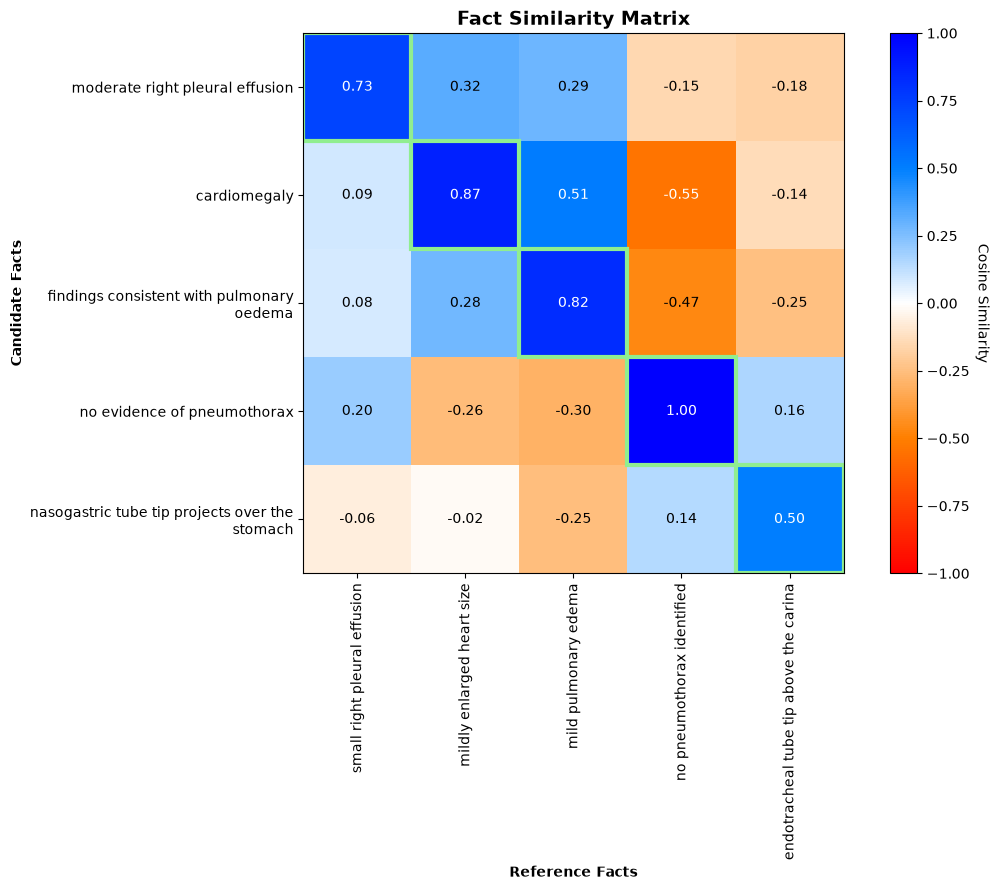


CXRFEScore for this pair: 0.7840


In [10]:
print("Encoder:", metric.encoder_model_name)
cxrfe_multi = metric([multi_hyp], [multi_ref])
print("pair similarity (CXRFE):", float(cxrfe_multi["per_pair_similarity"][0]))

metric.visualize_fact_similarity(
    ref_report=multi_ref,
    cand_report=multi_hyp,
    figsize=(12, 9),
)

### 7b. Visualization with SRR-BERT-Leaves

This downloads a second encoder on first use.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Encoder: StanfordAIMI/SRR-BERT-Leaves


Extracting facts:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Computing pair-wise similarity:   0%|          | 0/1 [00:00<?, ?it/s]

pair similarity (SRR-BERT-Leaves): 0.8778446316719055
--- Candidate Report (Y-axis) ---
Moderate right pleural effusion. Cardiomegaly is present. Findings consistent with pulmonary oedema. No evidence of pneumothorax. Nasogastric tube tip projects over the stomach.

--- Extracted Candidate Facts ---
- moderate right pleural effusion
- cardiomegaly
- findings consistent with pulmonary oedema
- no evidence of pneumothorax
- nasogastric tube tip projects over the stomach

--- Reference Report (X-axis) ---
There is a small right pleural effusion. The heart size is mildly enlarged. Mild pulmonary edema is present. No pneumothorax is identified. The endotracheal tube tip is above the carina.

--- Extracted Reference Facts ---
- small right pleural effusion
- mildly enlarged heart size
- mild pulmonary edema
- no pneumothorax identified
- endotracheal tube tip above the carina


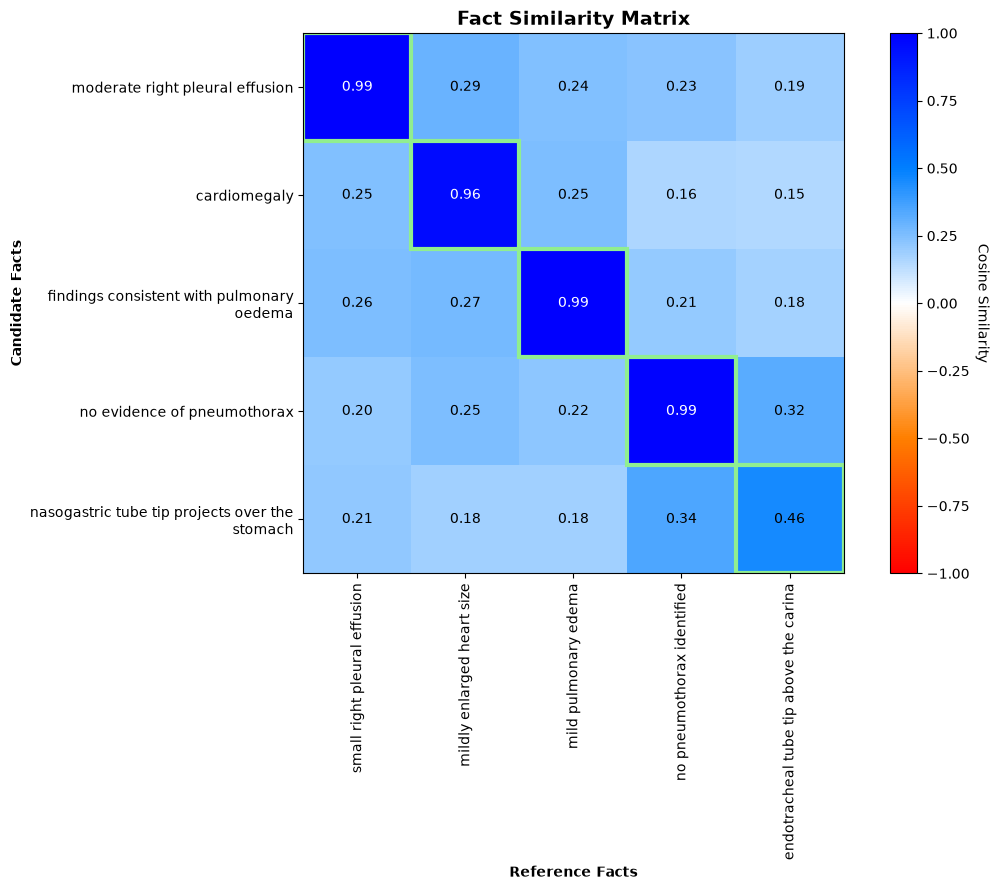


CXRFEScore for this pair: 0.8778


In [11]:
metric_srr = CXRFEScore(
    encoder_model_name="StanfordAIMI/SRR-BERT-Leaves",
    device=device,
    batch_size=8,
    num_workers=0,
    verbose=True,
)

print("Encoder:", metric_srr.encoder_model_name)
srr_multi = metric_srr([multi_hyp], [multi_ref])
print("pair similarity (SRR-BERT-Leaves):", float(srr_multi["per_pair_similarity"][0]))

metric_srr.visualize_fact_similarity(
    ref_report=multi_ref,
    cand_report=multi_hyp,
    figsize=(12, 9),
)

## 8. Optional: adversarial heatmaps (CXRFE)

Uncomment / run to inspect fact-level alignments for each challenging pair.


Negation flip (should score LOW)
Nearly identical wording, opposite clinical meaning.
--- Candidate Report (Y-axis) ---
There is evidence of pneumothorax.

--- Extracted Candidate Facts ---
- evidence of pneumothorax

--- Reference Report (X-axis) ---
There is no evidence of pneumothorax.

--- Extracted Reference Facts ---
- no evidence of pneumothorax


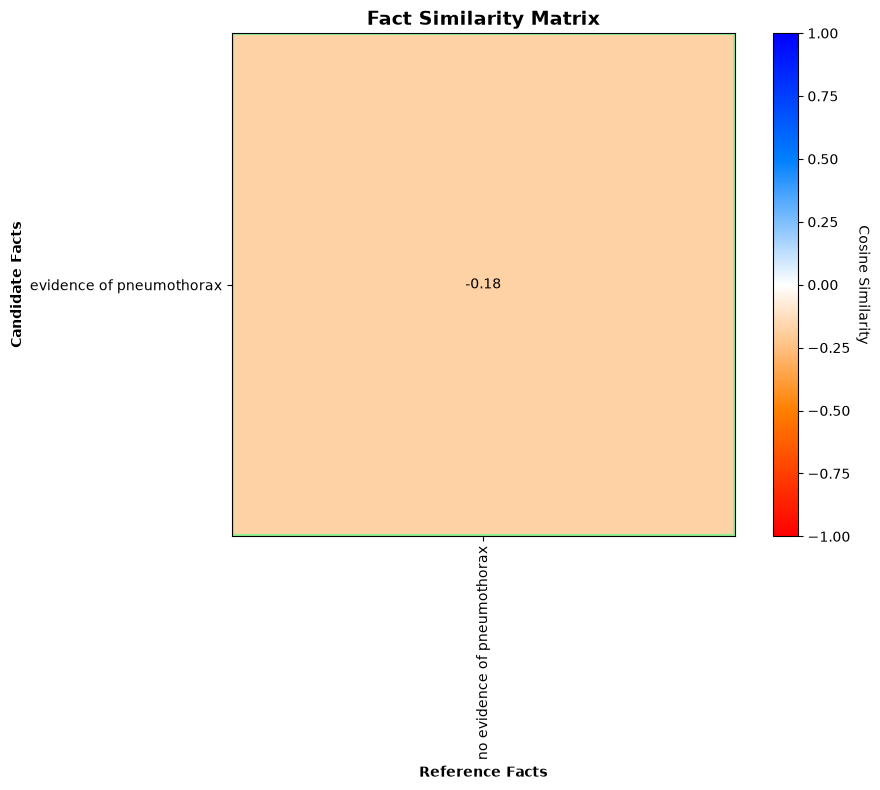


CXRFEScore for this pair: -0.1796

Laterality swap (should score LOW)
Same finding, wrong side — clinically important error.
--- Candidate Report (Y-axis) ---
Moderate left pleural effusion.

--- Extracted Candidate Facts ---
- moderate left pleural effusion

--- Reference Report (X-axis) ---
Moderate right pleural effusion.

--- Extracted Reference Facts ---
- moderate right pleural effusion


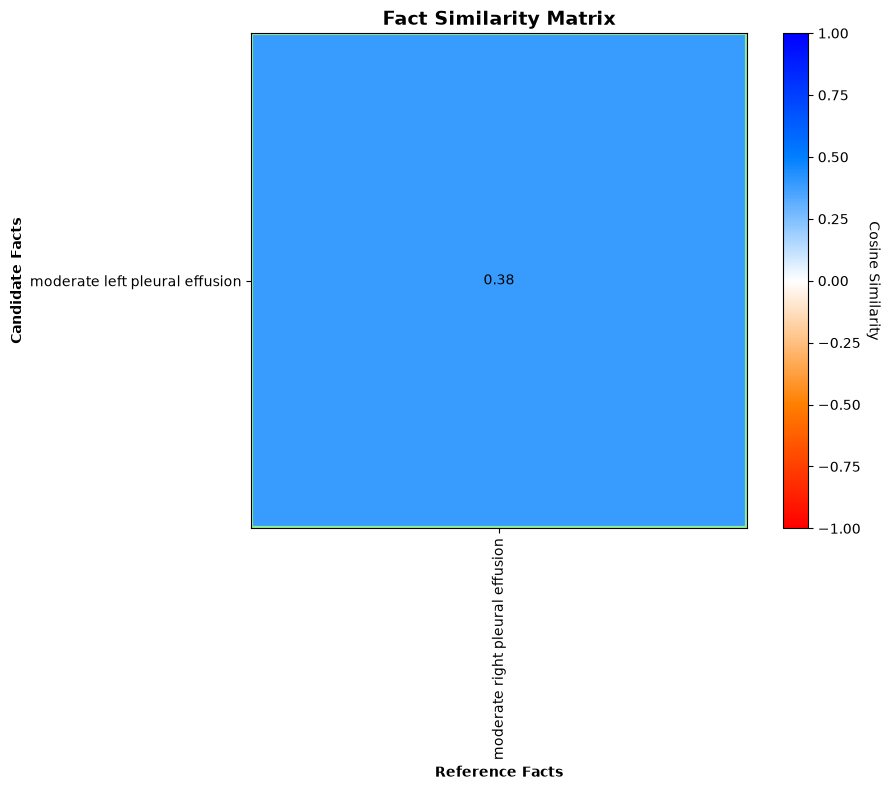


CXRFEScore for this pair: 0.3834

Severity / size swap (should score MID-LOW)
Correct finding/side, wrong magnitude.
--- Candidate Report (Y-axis) ---
Large right pleural effusion.

--- Extracted Candidate Facts ---
- large right pleural effusion

--- Reference Report (X-axis) ---
Small right pleural effusion.

--- Extracted Reference Facts ---
- small right pleural effusion


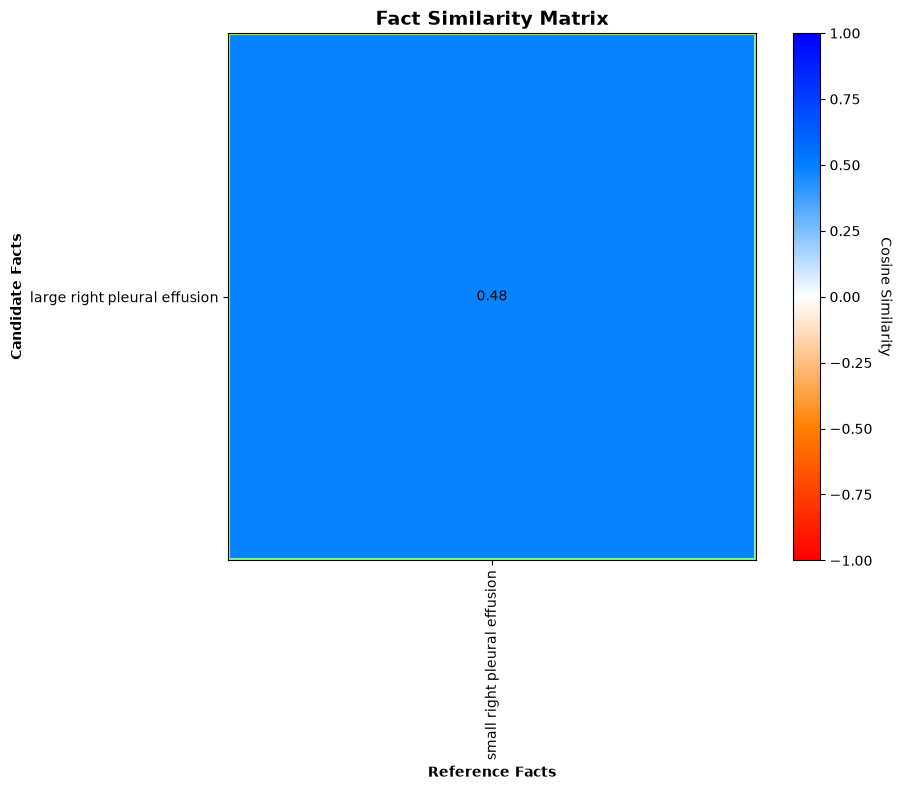


CXRFEScore for this pair: 0.4808

Synonym paraphrase (should score HIGH)
Different wording, same meaning — robustness check.
--- Candidate Report (Y-axis) ---
Cardiomegaly is present. Findings consistent with pulmonary oedema.

--- Extracted Candidate Facts ---
- cardiomegaly
- findings consistent with pulmonary oedema

--- Reference Report (X-axis) ---
The heart is enlarged. There is pulmonary edema.

--- Extracted Reference Facts ---
- enlarged heart
- pulmonary edema


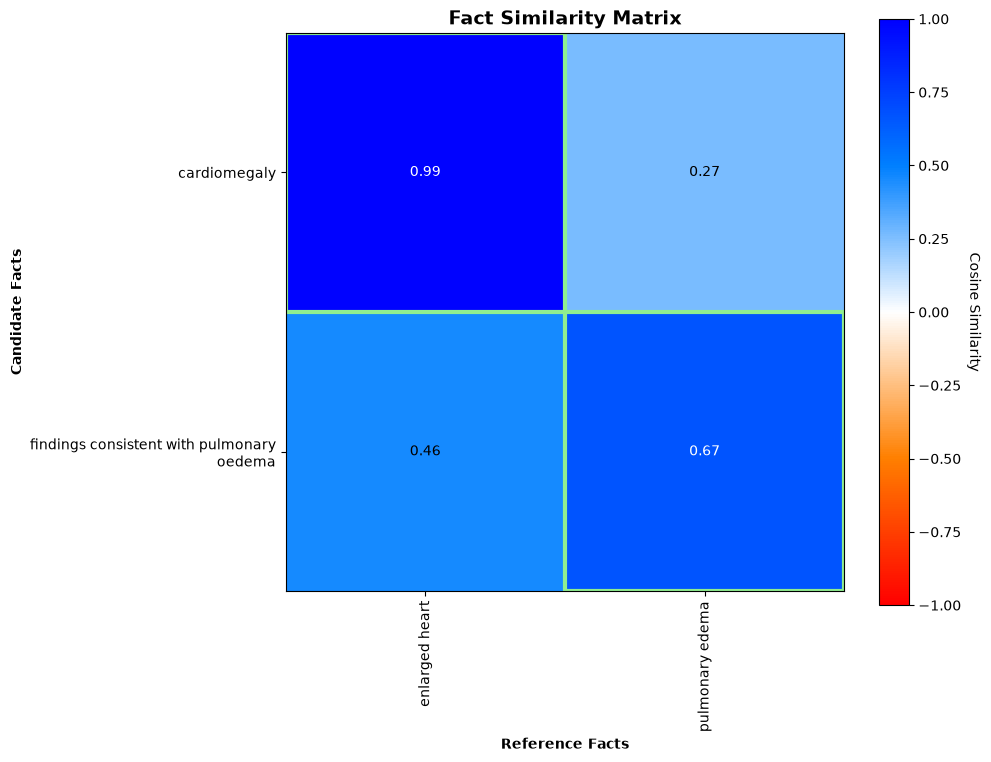


CXRFEScore for this pair: 0.8275

Presence vs absence of shared anatomy (should score LOW)
Shares anatomy tokens but asserts opposite finding.
--- Candidate Report (Y-axis) ---
There is focal consolidation in the lungs.

--- Extracted Candidate Facts ---
- focal consolidation in the lungs

--- Reference Report (X-axis) ---
The lungs are clear without focal consolidation.

--- Extracted Reference Facts ---
- clear lungs
- lungs without focal consolidation


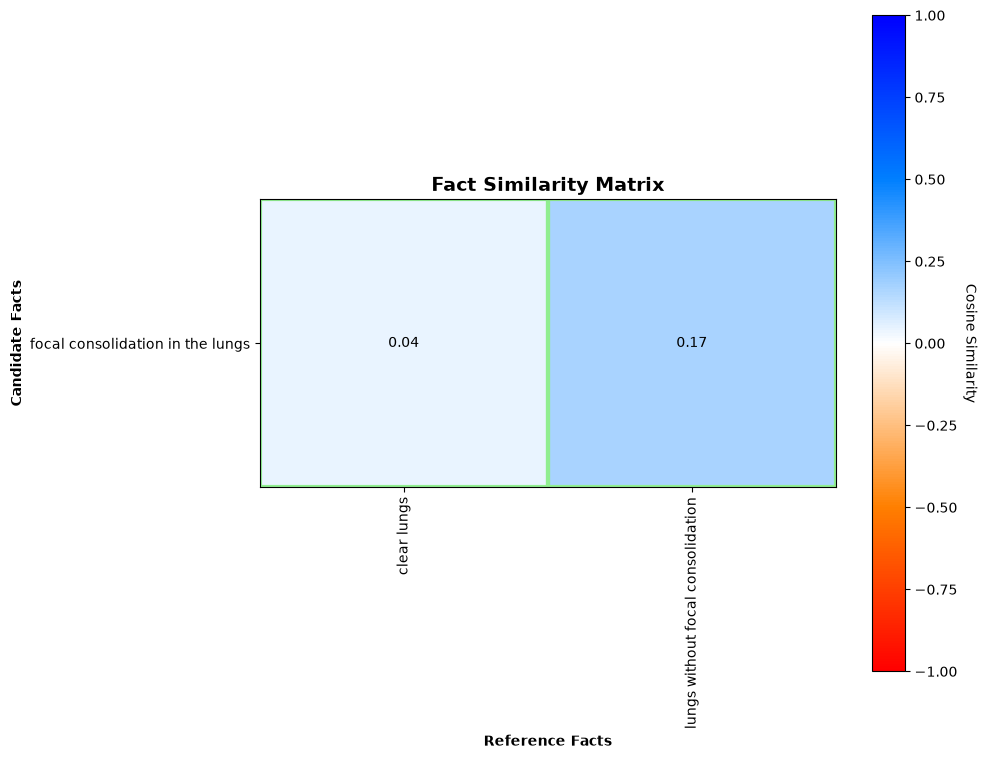


CXRFEScore for this pair: 0.1347

Device / support device mismatch (should score LOW)
Support-device facts often confuse overlap-based metrics.
--- Candidate Report (Y-axis) ---
Nasogastric tube tip is appropriately positioned in the stomach.

--- Extracted Candidate Facts ---
- nasogastric tube tip appropriately positioned in the stomach

--- Reference Report (X-axis) ---
Endotracheal tube tip is appropriately positioned above the carina.

--- Extracted Reference Facts ---
- endotracheal tube tip appropriately positioned above the carina


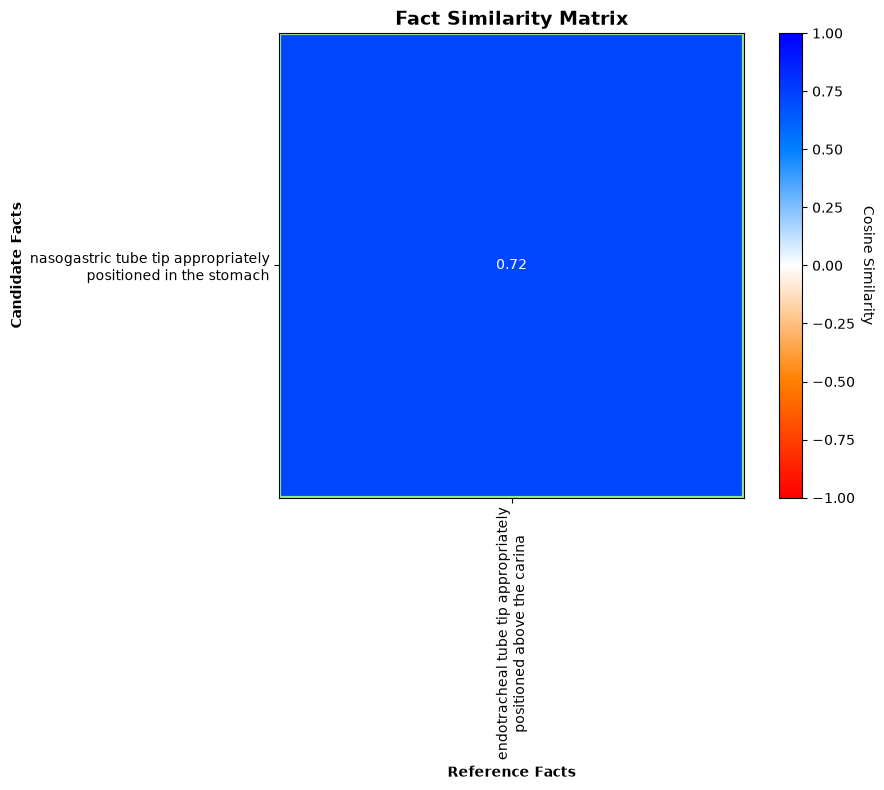


CXRFEScore for this pair: 0.7247


In [12]:
for case in adversarial_cases:
    print("\n" + "=" * 72)
    print(case["name"])
    print(case["note"])
    print("=" * 72)
    metric.visualize_fact_similarity(
        ref_report=case["ref"],
        cand_report=case["hyp"],
    )

## Citation

If you use CXRFEScore, please cite:

```bibtex
@inproceedings{messina-etal-2024-extracting,
    title = "Extracting and Encoding: Leveraging Large Language Models and Medical Knowledge to Enhance Radiological Text Representation",
    author = "Messina, Pablo  and
      Vidal, Rene  and
      Parra, Denis  and
      Soto, Alvaro  and
      Araujo, Vladimir",
    booktitle = "Findings of the Association for Computational Linguistics: ACL 2024",
    month = aug,
    year = "2024",
    address = "Bangkok, Thailand",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.findings-acl.236/",
    doi = "10.18653/v1/2024.findings-acl.236",
    pages = "3955--3986"
}
```